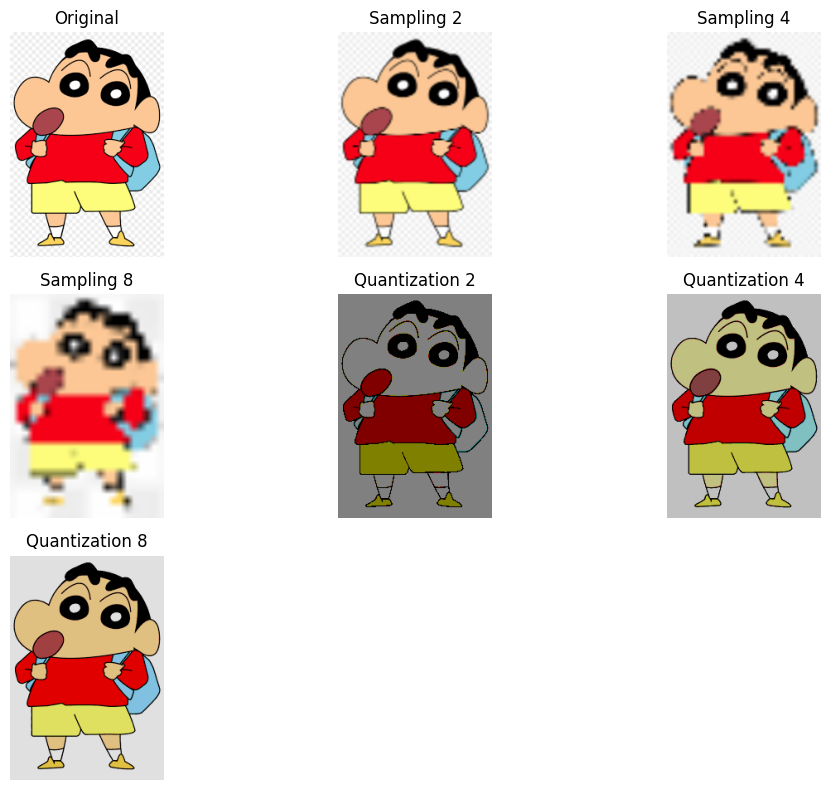

✅ Results saved in: D:\IPCV\LAB-EXP-2\resultant_img


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# 📁 PATHS
# ==============================
input_path = r"D:\IPCV\LAB-EXP-2\images\1.png"
output_folder = r"D:\IPCV\LAB-EXP-2\resultant_img"

os.makedirs(output_folder, exist_ok=True)

# ==============================
# 📷 LOAD IMAGE
# ==============================
img = cv2.imread(input_path)

if img is None:
    print("❌ Image not found.")
    exit()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# 🎯 SAMPLING FUNCTION
# ==============================
def sampling(image, factor):
    h, w = image.shape[:2]
    sampled = cv2.resize(image, (w//factor, h//factor))
    sampled = cv2.resize(sampled, (w, h))  # resize back for comparison
    return sampled

# ==============================
# 🎯 QUANTIZATION FUNCTION
# ==============================
def quantization(image, levels):
    step = 256 // levels
    quantized = (image // step) * step
    return quantized

# ==============================
# ⚙️ APPLY DIFFERENT LEVELS
# ==============================
sampling_factors = [2, 4, 8]
quant_levels = [2, 4, 8]

results = []

for s in sampling_factors:
    samp_img = sampling(img_rgb, s)
    cv2.imwrite(os.path.join(output_folder, f"sampling_{s}.png"),
                cv2.cvtColor(samp_img, cv2.COLOR_RGB2BGR))
    results.append(("Sampling " + str(s), samp_img))

for q in quant_levels:
    quant_img = quantization(img_rgb, q)
    cv2.imwrite(os.path.join(output_folder, f"quantization_{q}.png"),
                cv2.cvtColor(quant_img, cv2.COLOR_RGB2BGR))
    results.append(("Quantization " + str(q), quant_img))

# ==============================
# 🖼️ DISPLAY RESULTS
# ==============================
plt.figure(figsize=(10, 8))

plt.subplot(3, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

for i, (title, image) in enumerate(results):
    plt.subplot(3, 3, i+2)
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("✅ Results saved in:", output_folder)